# Prostate Cancer Cell Detection using Machine Learning
This machine learning project includes prostate cancer detection using both Convolutional Neural Networks (CNN) and Recurrent Neural Networks (RNN - LSTM).

In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load and Preprocess Dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Prostate_Cancer.csv')
df.drop(['id'], axis=1, inplace=True)

# Encode labels
df['diagnosis_result'] = LabelEncoder().fit_transform(df['diagnosis_result'])

# Separate features and target
X = df.drop('diagnosis_result', axis=1).values
y = df['diagnosis_result'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN and RNN
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
X_rnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Split
X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)
X_train_rnn, X_test_rnn, _, _ = train_test_split(X_rnn, y, test_size=0.2, random_state=42)

# One-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

Saving Prostate_Cancer.csv to Prostate_Cancer.csv


# Model 1: Convolutional Neural Network (CNN)

In [3]:
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

# Train CNN
cnn_model.fit(X_train_cnn, y_train_cat, epochs=20, validation_data=(X_test_cnn, y_test_cat))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466 (25.26 KB)

 Trainable params: 6,466 (25.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.6500 - loss: 0.6560 - val_accuracy: 0.7000 - val_loss: 0.6208
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8375 - loss: 0.5968 - val_accuracy: 0.7000 - val_loss: 0.5839
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8375 - loss: 0.5501 - val_accuracy: 0.7000 - val_loss: 0.5524
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8500 - loss: 0.5119 - val_accuracy: 0.7000 - val_loss: 0.5295
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8500 - loss: 0.4791 - val_accuracy: 0.7500 - val_loss: 0.5154
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8500 - loss: 0.4490 - val_accuracy: 0.7500 - val_loss: 0.5083
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8750 - loss: 0.4253 - val_accuracy: 0.7500 - val_loss: 0.5079
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8750 - loss: 0.4022 - val_accuracy: 0.7000 - val_loss: 0.5103

# Model 2: Recurrent Neural Network (RNN - LSTM)

In [4]:
rnn_model = Sequential([
    LSTM(64, input_shape=(X_rnn.shape[1], 1)),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

# Train RNN
rnn_model.fit(X_train_rnn, y_train_cat, epochs=20, validation_data=(X_test_rnn, y_test_cat))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,186 (82.76 KB)

 Trainable params: 21,186 (82.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - accuracy: 0.7125 - loss: 0.6747 - val_accuracy: 0.7500 - val_loss: 0.6546
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7375 - loss: 0.6529 - val_accuracy: 0.6500 - val_loss: 0.6396
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7375 - loss: 0.6271 - val_accuracy: 0.7000 - val_loss: 0.6255
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7500 - loss: 0.6077 - val_accuracy: 0.7000 - val_loss: 0.6111
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7500 - loss: 0.5841 - val_accuracy: 0.7500 - val_loss: 0.5977
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7625 - loss: 0.5635 - val_accuracy: 0.7000 - val_loss: 0.5837
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7750 - loss: 0.5375 - val_accuracy: 0.7000 - val_loss: 0.5712
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7750 - loss: 0.5163 - val_accuracy: 0.7000 - val_loss: 0.5624

# Evaluation

In [5]:
cnn_preds = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
print("CNN Classification Report:")
print(classification_report(y_test, cnn_preds))

rnn_preds = np.argmax(rnn_model.predict(X_test_rnn), axis=1)
print("RNN Classification Report:")
print(classification_report(y_test, rnn_preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
CNN Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         4
           1       0.82      0.88      0.85        16

    accuracy                           0.75        20
   macro avg       0.58      0.56      0.57        20
weighted avg       0.73      0.75      0.74        20

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
RNN Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.25      0.25         4
           1       0.81      0.81      0.81        16

    accuracy                           0.70        20
   macro avg       0.53      0.53      0.53        20
weighted avg       0.70      0.70      0.70        20



### Malingnant VS Benign

In [6]:
# Predict class probabilities for all patients
cnn_probs = cnn_model.predict(X_cnn)

# Take first 20 patients only
top20_probs = cnn_probs[:20]

# Create a DataFrame
top20_df = pd.DataFrame({
    'Benign_Probability': top20_probs[:, 0],
    'Malignant_Probability': top20_probs[:, 1],
    'Predicted_Diagnosis': ['Benign' if p[0] > p[1] else 'Malignant' for p in top20_probs]
})

# Display the table
top20_df

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,Benign_Probability,Malignant_Probability,Predicted_Diagnosis
0,0.001623,0.998377,Malignant
1,0.055200,0.944800,Malignant
2,0.019460,0.980540,Malignant
3,0.151753,0.848247,Malignant
4,0.021166,0.978834,Malignant
5,0.226855,0.773145,Malignant
6,0.027996,0.972004,Malignant
7,0.211653,0.788347,Malignant
8,0.108010,0.891990,Malignant
9,0.139911,0.860089,Malignant


# Visualization - Pie Chart

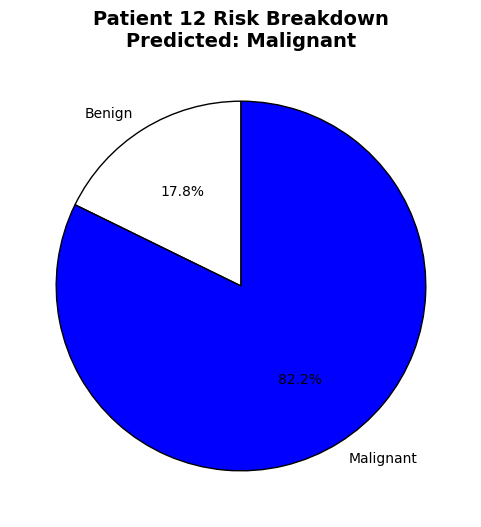

In [7]:
import matplotlib.pyplot as plt

# Choose a patient
i = 11

# Data
benign = top20_df.loc[i, 'Benign_Probability']
malignant = top20_df.loc[i, 'Malignant_Probability']
diagnosis = top20_df.loc[i, 'Predicted_Diagnosis']

# Pie chart
colors = ['white', 'blue']
labels = ['Benign', 'Malignant']
sizes = [benign, malignant]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, startangle=90, autopct='%1.1f%%', wedgeprops={'linewidth': 1, 'edgecolor': 'black'})
plt.title(f"Patient {i+1} Risk Breakdown\nPredicted: {diagnosis}", fontsize=14, weight='bold')
plt.show()

# Visualization - Diagonsis Comparison

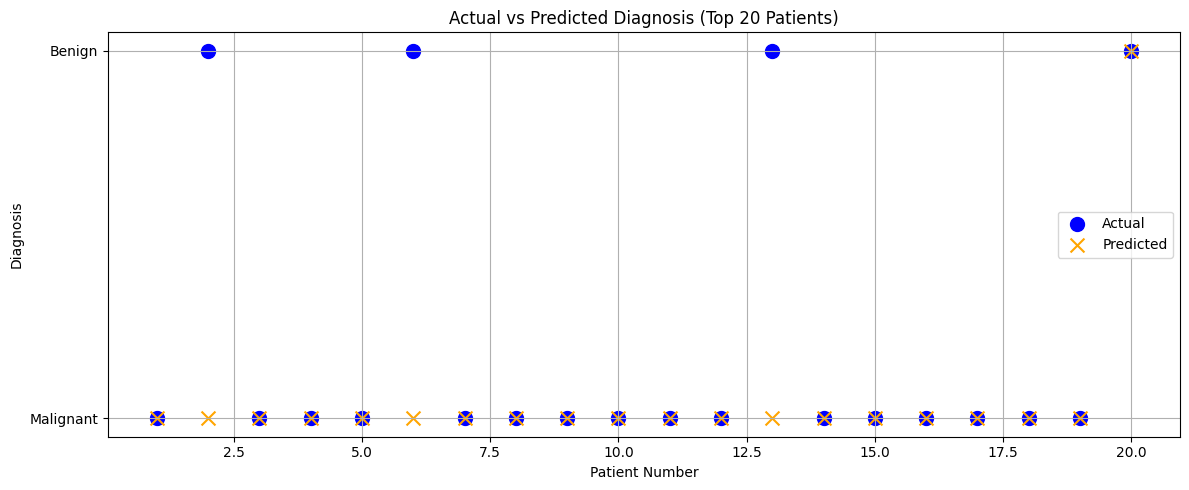

In [8]:
# Actual diagnosis to dataframe
top20_df['Actual_Diagnosis'] = ['Benign' if i == 0 else 'Malignant' for i in y[:20]]

# Comparison plot
plt.figure(figsize=(12, 5))
plt.scatter(range(1, 21), top20_df['Actual_Diagnosis'], color='blue', label='Actual', marker='o', s=100)
plt.scatter(range(1, 21), top20_df['Predicted_Diagnosis'], color='orange', label='Predicted', marker='x', s=100)
plt.title("Actual vs Predicted Diagnosis (Top 20 Patients)")
plt.xlabel("Patient Number")
plt.ylabel("Diagnosis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualization - Line plot

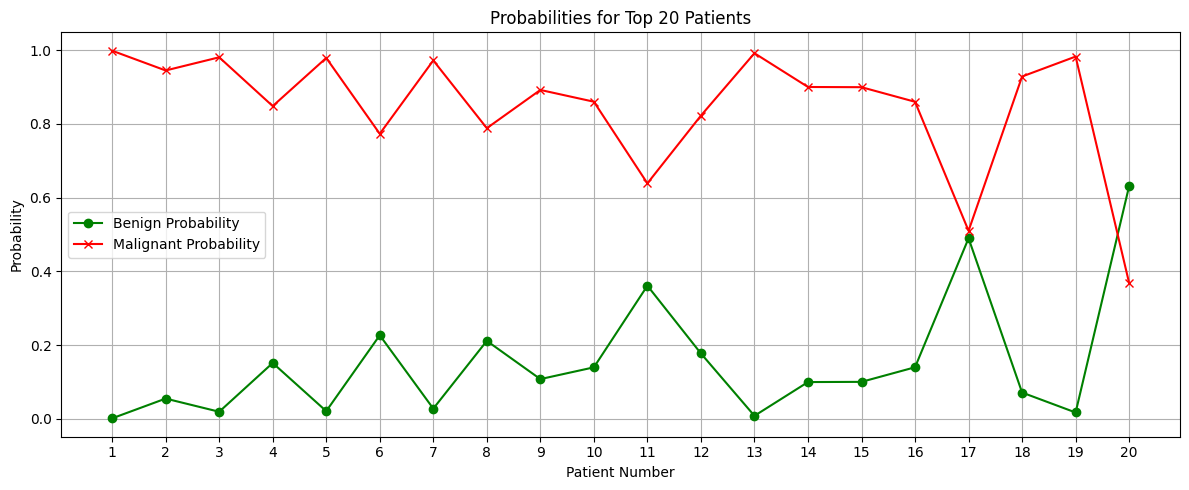

In [9]:
# Line plot
patients = np.arange(1, 21)
plt.figure(figsize=(12, 5))
plt.plot(patients, top20_df['Benign_Probability'], marker='o', label='Benign Probability', color='green')
plt.plot(patients, top20_df['Malignant_Probability'], marker='x', label='Malignant Probability', color='red')

plt.xlabel('Patient Number')
plt.ylabel('Probability')
plt.title('Probabilities for Top 20 Patients')
plt.xticks(patients)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()